In [114]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

In [115]:
data = pd.read_csv("loan_data.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [116]:
data["Loan_Approved"]

0       No
1       No
2      Yes
3       No
4      Yes
      ... 
995     No
996     No
997     No
998    Yes
999     No
Name: Loan_Approved, Length: 1000, dtype: object

In [117]:
data.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [118]:
loan_approved_map = {
    "yes":1,
    "no":0
}

data.columns = [i.lower() for i in data.columns]

In [119]:
categorical_col = data.select_dtypes(include=["object"]).columns
num_col = data.select_dtypes(include=["number"]).columns

In [120]:
num_imp = SimpleImputer(strategy="mean")
data[num_col] = num_imp.fit_transform(data[num_col])
cat_imp =  SimpleImputer(strategy="most_frequent")
data[categorical_col] = cat_imp.fit_transform(data[categorical_col])

In [121]:
data.isnull().sum()

applicant_id          0
applicant_income      0
coapplicant_income    0
employment_status     0
age                   0
marital_status        0
dependents            0
credit_score          0
existing_loans        0
dti_ratio             0
savings               0
collateral_value      0
loan_amount           0
loan_term             0
loan_purpose          0
property_area         0
education_level       0
gender                0
employer_category     0
loan_approved         0
dtype: int64

([<matplotlib.patches.Wedge at 0x29df4fae990>,
 [Text(-0.6521425632196803, 0.8858386293435534, 'Yes'),
  Text(0.6521426461578755, -0.8858385682855563, 'No')],
 [Text(-0.35571412539255287, 0.4831847069146654, '70.2%'),
  Text(0.3557141706315684, -0.4831846736103034, '29.8%')])

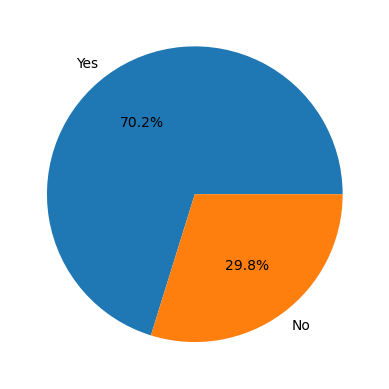

In [122]:
plt.pie(data["loan_approved"].value_counts(),labels = ["Yes","No"],autopct="%1.1f%%")


<Axes: xlabel='gender', ylabel='count'>

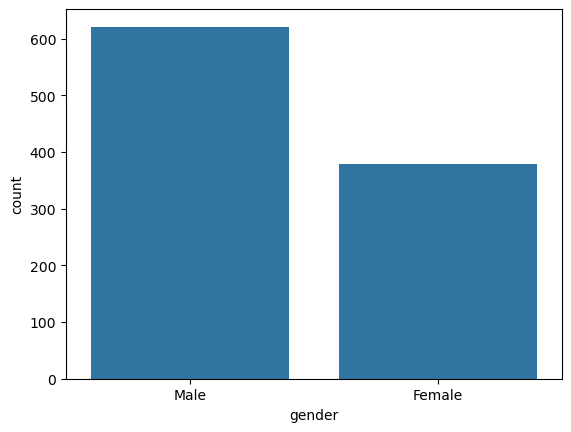

In [123]:
gender_count = data["gender"].value_counts()
sns.barplot(gender_count)

<Axes: xlabel='education_level', ylabel='count'>

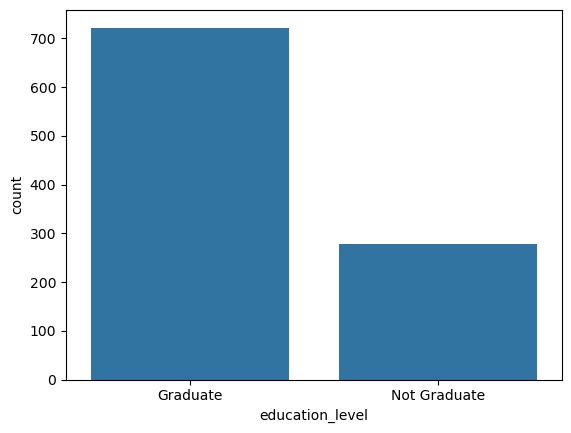

In [124]:
edu_lvl = data["education_level"].value_counts()
sns.barplot(edu_lvl)

([<matplotlib.patches.Wedge at 0x29df533c740>,
 [Text(-0.6521425632196803, 0.8858386293435534, 'No'),
  Text(0.6521426461578755, -0.8858385682855563, 'Yes')],
 [Text(-0.35571412539255287, 0.4831847069146654, '70.2%'),
  Text(0.3557141706315684, -0.4831846736103034, '29.8%')])

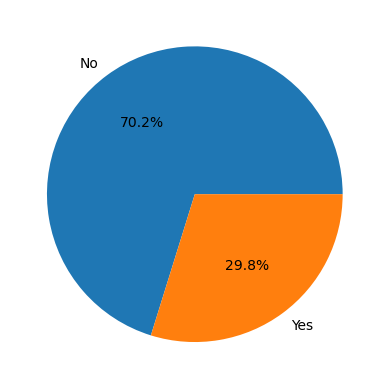

In [125]:
classes_count = data["loan_approved"].value_counts()
plt.pie(classes_count,labels=["No","Yes"],autopct="%1.1f%%")

<Axes: xlabel='gender', ylabel='count'>

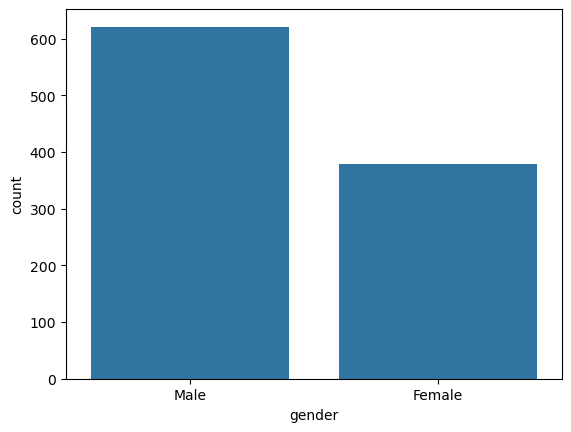

In [126]:
gender_count
sns.barplot(gender_count)

<Axes: xlabel='applicant_income', ylabel='Count'>

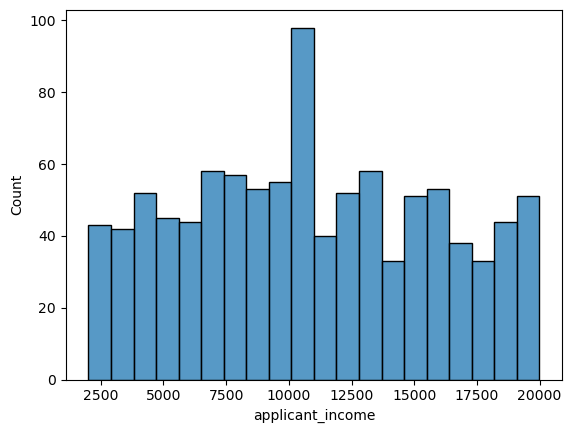

In [127]:
sns.histplot(data=data,
    x="applicant_income",
    bins=20
)

<Axes: xlabel='coapplicant_income', ylabel='Count'>

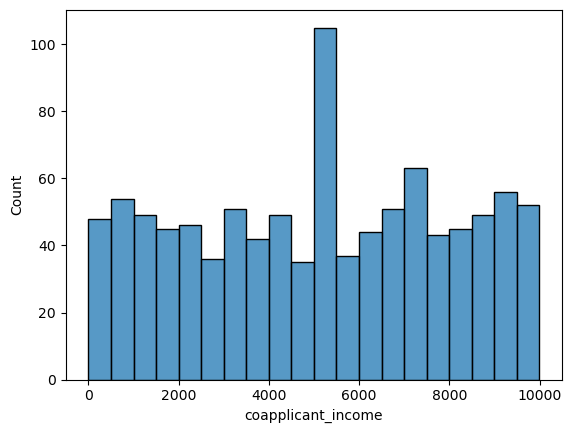

In [128]:
sns.histplot(data=data,
    x="coapplicant_income",
    bins=20
)

<Axes: xlabel='loan_approved', ylabel='applicant_income'>

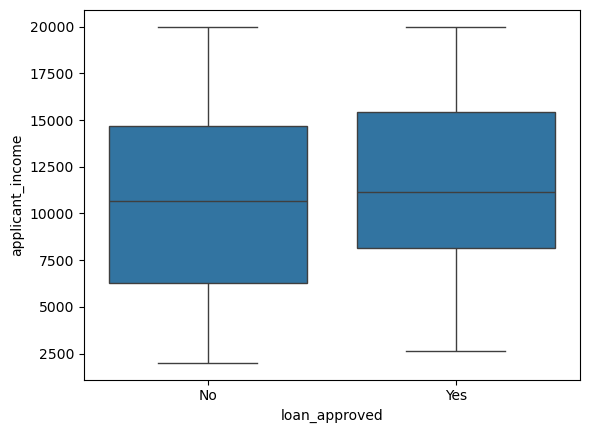

In [129]:
sns.boxplot(
    data=data,
    x="loan_approved",
    y="applicant_income"
)

#Usually, rejected loans had lower income than accepted

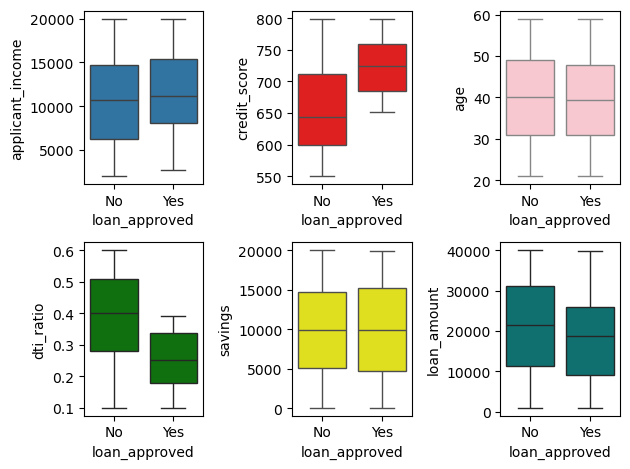

In [130]:
fig,axes = plt.subplots(2,3)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "applicant_income",
    ax=axes[0,0]
)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "credit_score",
    ax=axes[0,1],
    color="red"
)
sns.boxplot(
    data=data,
    x="loan_approved",
    y="age",
    ax=axes[0,2],
    color="pink"
)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "dti_ratio",
    ax=axes[1,0],
    color="green"
)
sns.boxplot(
    data = data,
    x="loan_approved",
    y = "savings",
    ax=axes[1,1],
    color="yellow"
)
sns.boxplot(
    data=data,
    x="loan_approved",
    y="loan_amount",
    ax=axes[1,2],
    color="teal"
)
plt.tight_layout()

<Axes: xlabel='credit_score', ylabel='Count'>

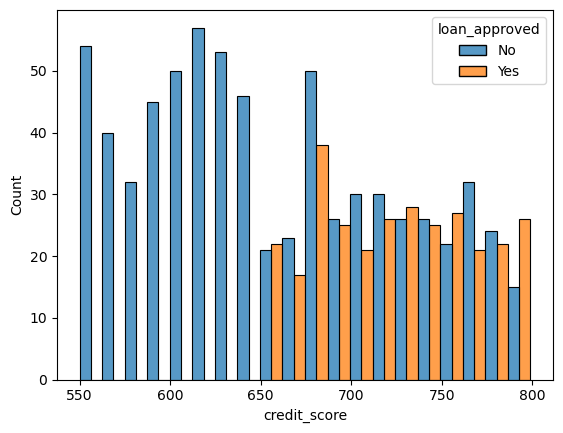

In [131]:
sns.histplot(
    data,
    x="credit_score",
    hue="loan_approved",
    bins=20,
    multiple="dodge"
)

<Axes: xlabel='applicant_income', ylabel='Count'>

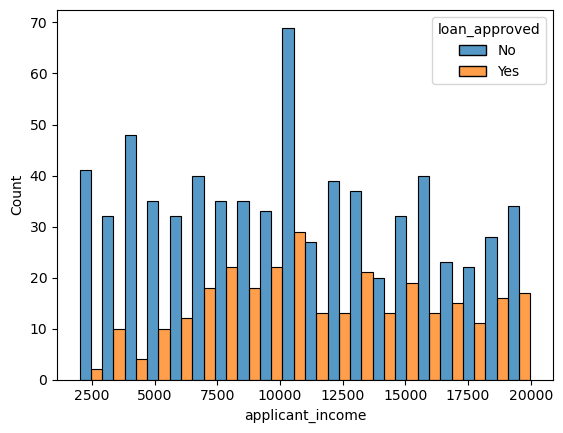

In [132]:
sns.histplot(
    data,
    x="applicant_income",
    hue="loan_approved",
    bins=20,
    multiple="dodge"
)

In [133]:
#Remove applicant id
data

,applicant_id,applicant_income,coapplicant_income,employment_status,age,marital_status,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,loan_amount,loan_term,loan_purpose,property_area,education_level,gender,employer_category,loan_approved
0,1.0,17795.000000,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.000000,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.000000,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.000000,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.000000,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.000000,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.000000,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.000000,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.000000,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.000000,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996.0,10852.571579,9092.0,Salaried,58.0,Married,0.0,557.0,0.0,0.59,5370.000000,43563.0,8311.0,72.0,Personal,Urban,Not Graduate,Male,Unemployed,No
996,997.0,3279.000000,6356.0,Self-employed,58.0,Married,1.0,646.0,3.0,0.19,9940.452632,18361.0,22563.0,12.0,Business,Urban,Graduate,Female,Government,No
997,998.0,15192.000000,8433.0,Contract,48.0,Single,1.0,666.0,1.0,0.40,8581.000000,41335.0,16203.0,24.0,Home,Rural,Graduate,Male,MNC,No
998,999.0,9083.000000,7380.0,Unemployed,50.0,Single,1.0,748.0,3.0,0.31,13491.000000,8933.0,10290.0,36.0,Personal,Urban,Graduate,Male,Private,Yes


In [134]:

data.head()

,applicant_id,applicant_income,coapplicant_income,employment_status,age,marital_status,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,loan_amount,loan_term,loan_purpose,property_area,education_level,gender,employer_category,loan_approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [135]:
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
data.columns

Index(['applicant_id', 'applicant_income', 'coapplicant_income',
       'employment_status', 'age', 'marital_status', 'dependents',
       'credit_score', 'existing_loans', 'dti_ratio', 'savings',
       'collateral_value', 'loan_amount', 'loan_term', 'loan_purpose',
       'property_area', 'education_level', 'gender', 'employer_category',
       'loan_approved'],
      dtype='object')

In [136]:
label_encoder = LabelEncoder()
data["education_level"] = label_encoder.fit_transform(data["education_level"])
data["loan_approved"] = label_encoder.fit_transform(data["loan_approved"])


In [137]:
data.head()

,applicant_id,applicant_income,coapplicant_income,employment_status,age,marital_status,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,loan_amount,loan_term,loan_purpose,property_area,education_level,gender,employer_category,loan_approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [138]:
one_hot_encoder = OneHotEncoder(
    drop="first",
    sparse_output=False,
    handle_unknown="ignore"
)
one_hot_cols = ["employment_status","marital_status","loan_purpose","property_area","gender","employer_category"]
encoded = one_hot_encoder.fit_transform(data[one_hot_cols])
print(encoded)
one_hot_encoder.get_feature_names_out(one_hot_cols)

[[1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 1. ... 0. 1. 0.]
 [1. 0. 0. ... 0. 1. 0.]]


array(['employment_status_Salaried', 'employment_status_Self-employed',
       'employment_status_Unemployed', 'marital_status_Single',
       'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home',
       'loan_purpose_Personal', 'property_area_Semiurban',
       'property_area_Urban', 'gender_Male',
       'employer_category_Government', 'employer_category_MNC',
       'employer_category_Private', 'employer_category_Unemployed'],
      dtype=object)

In [139]:
encoded_df = pd.DataFrame(
    encoded,
    columns=one_hot_encoder.get_feature_names_out(one_hot_cols),
    index=data.index
)

data = pd.concat([data.drop(columns=one_hot_cols),encoded_df],axis=1)

In [140]:
data.head()

,applicant_id,applicant_income,coapplicant_income,age,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,...,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,property_area_Semiurban,property_area_Urban,gender_Male,employer_category_Government,employer_category_MNC,employer_category_Private,employer_category_Unemployed
0,1.0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,3.0,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,4.0,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,5.0,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [141]:
data.columns = [i.lower() for i in data.columns]

In [142]:
num_cols = data.select_dtypes("number")
corr_matrix = num_cols.corr()

In [143]:
corr_matrix

,applicant_id,applicant_income,coapplicant_income,age,dependents,credit_score,existing_loans,dti_ratio,savings,collateral_value,...,loan_purpose_education,loan_purpose_home,loan_purpose_personal,property_area_semiurban,property_area_urban,gender_male,employer_category_government,employer_category_mnc,employer_category_private,employer_category_unemployed
applicant_id,1.000000,0.020970,0.041140,0.014579,0.012495,-0.028170,0.024995,0.000174,0.022692,0.031759,...,0.005426,-0.039878,0.019178,0.012969,-0.030187,0.036067,0.005906,-0.074056,0.022803,0.038417
applicant_income,0.020970,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
coapplicant_income,0.041140,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
age,0.014579,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
dependents,0.012495,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
credit_score,-0.028170,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
existing_loans,0.024995,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
dti_ratio,0.000174,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
savings,0.022692,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
collateral_value,0.031759,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655


In [144]:
num_cols.corr()["loan_approved"].sort_values(ascending=False)

loan_approved                      1.000000
credit_score                       0.451175
applicant_income                   0.119796
employer_category_mnc              0.069049
loan_purpose_personal              0.034043
marital_status_single              0.030182
property_area_urban                0.025963
collateral_value                   0.021868
coapplicant_income                 0.004230
loan_purpose_home                  0.002118
employment_status_self-employed   -0.001337
employer_category_private         -0.003347
applicant_id                      -0.011167
property_area_semiurban           -0.012967
savings                           -0.013437
loan_purpose_education            -0.016684
employer_category_unemployed      -0.021468
age                               -0.022343
dependents                        -0.023811
existing_loans                    -0.034794
employer_category_government      -0.039187
employment_status_salaried        -0.041428
employment_status_unemployed    

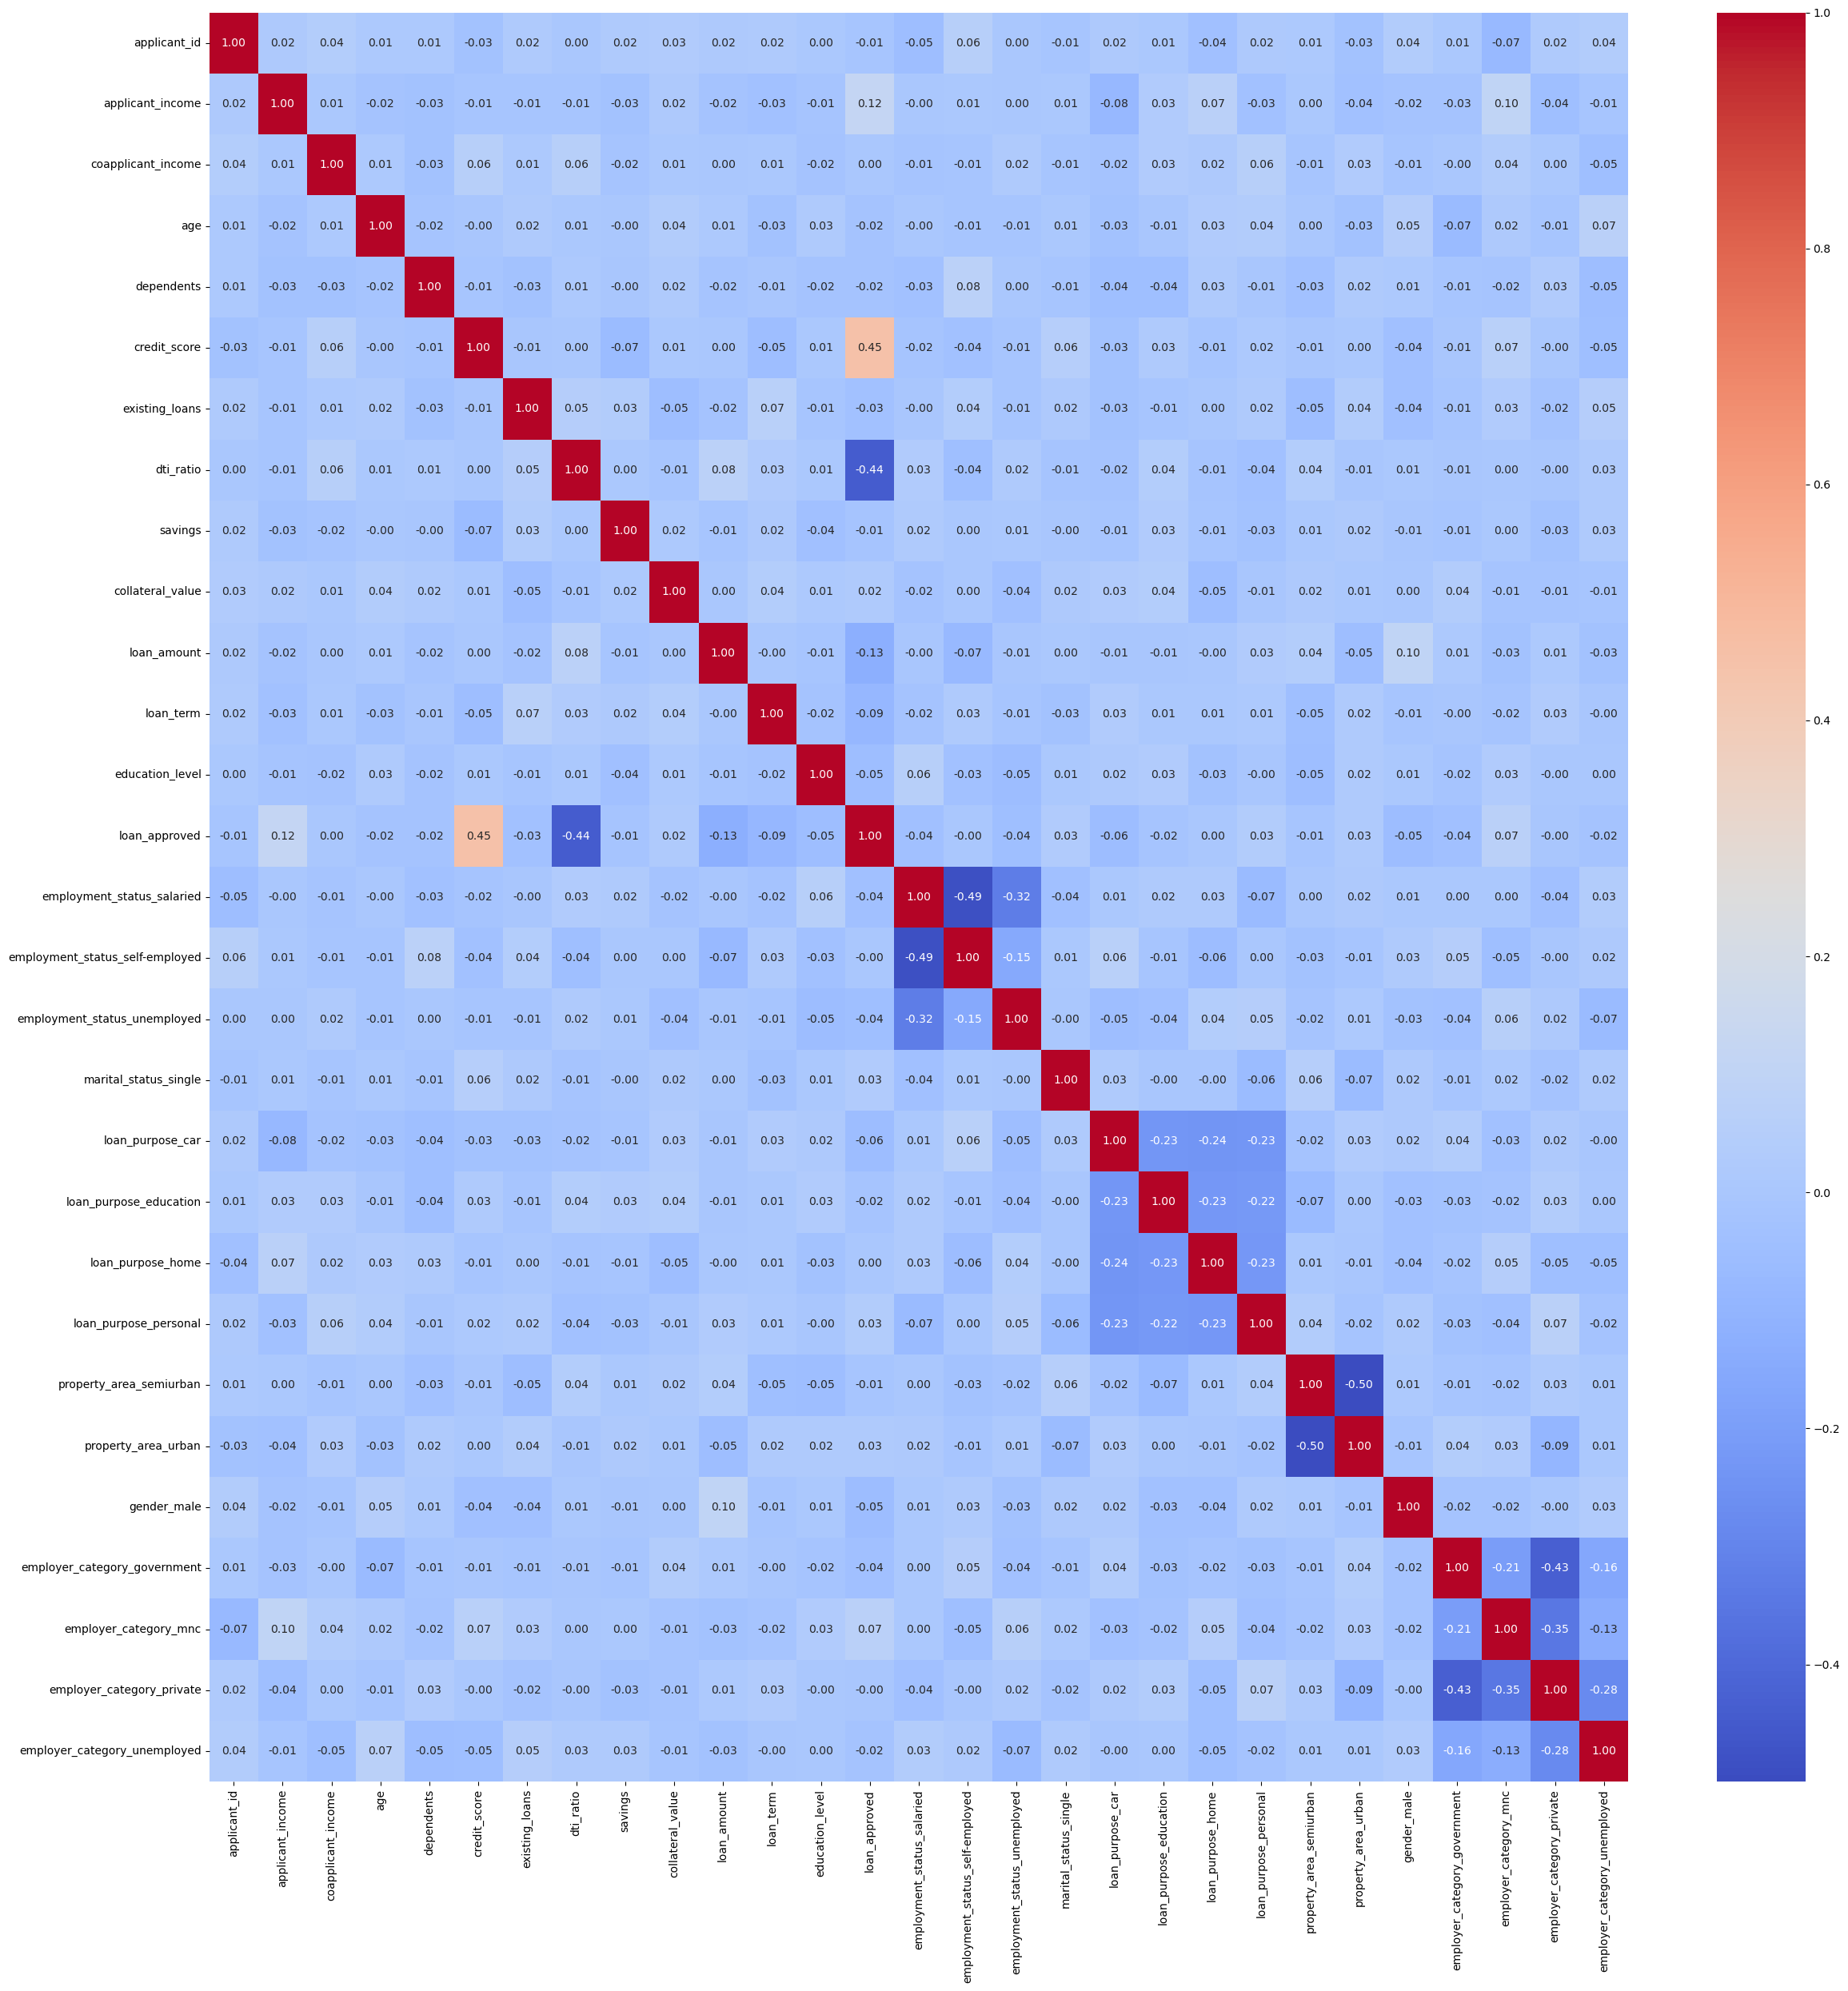

In [145]:
plt.figure(figsize=(25,25))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()

#There doesnt exist much correlation: Dont prefer linear models. Go for decision trees.

In [146]:
X = data.drop(columns=["loan_approved"])
Y = data["loan_approved"]

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Logistic Regression

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled,Y_train)

y_predicted = logistic_model.predict(X_test_scaled)

print("Logistic Regression")
print("Precision:",precision_score(Y_test,y_pred=y_predicted))
print("Recall:",recall_score(Y_test,y_pred=y_predicted))
print("F1:",f1_score(Y_test,y_pred=y_predicted))
print("Accuracy:",accuracy_score(Y_test,y_pred=y_predicted))

print(confusion_matrix(Y_test,y_predicted))

#Maximise precision

Logistic Regression
Precision: 0.7868852459016393
Recall: 0.7868852459016393
F1: 0.7868852459016393
Accuracy: 0.87
[[126  13]
 [ 13  48]]


# K-Nearest Neighbors

In [148]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled,Y_train)

y_predicted = knn_model.predict(X_test_scaled)

print("K Nearest Neighbors")
print("Precision:",precision_score(Y_test,y_pred=y_predicted))
print("Recall:",recall_score(Y_test,y_pred=y_predicted))
print("F1:",f1_score(Y_test,y_pred=y_predicted))
print("Accuracy:",accuracy_score(Y_test,y_pred=y_predicted))

print(confusion_matrix(Y_test,y_predicted))

K Nearest Neighbors
Precision: 0.6428571428571429
Recall: 0.4426229508196721
F1: 0.5242718446601942
Accuracy: 0.755
[[124  15]
 [ 34  27]]


# Naive Bayes

In [149]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled,Y_train)

y_predicted = nb_model.predict(X_test_scaled)

print("Naive Bayes")
print("Precision:",precision_score(Y_test,y_pred=y_predicted))
print("Recall:",recall_score(Y_test,y_pred=y_predicted))
print("F1:",f1_score(Y_test,y_pred=y_predicted))
print("Accuracy:",accuracy_score(Y_test,y_pred=y_predicted))

print(confusion_matrix(Y_test,y_predicted))

Naive Bayes
Precision: 0.8035714285714286
Recall: 0.7377049180327869
F1: 0.7692307692307693
Accuracy: 0.865
[[128  11]
 [ 16  45]]


# Feature engineering

In [150]:
data["dti_ratio_sq"] = data["dti_ratio"]**2
data["credit_score_sq"] = data["credit_score"]**2

# data["applicant_income_log"] = np.log1p(data["applicant_income"])

X =data.drop(columns=["loan_approved","dti_ratio","credit_score"])
Y = data["loan_approved"]

X_train,X_test,Y_train,Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [151]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,classification_report,confusion_matrix
logistic_model = LogisticRegression()
logistic_model.fit(X_train_scaled,Y_train)

y_predicted = logistic_model.predict(X_test_scaled)

print("Logistic Regression")
print("Precision:",precision_score(Y_test,y_pred=y_predicted))
print("Recall:",recall_score(Y_test,y_pred=y_predicted))
print("F1:",f1_score(Y_test,y_pred=y_predicted))
print("Accuracy:",accuracy_score(Y_test,y_pred=y_predicted))

print(confusion_matrix(Y_test,y_predicted))

#Maximise precision

Logistic Regression
Precision: 0.7903225806451613
Recall: 0.8032786885245902
F1: 0.7967479674796748
Accuracy: 0.875
[[126  13]
 [ 12  49]]


# K-Nearest Neighbors

In [152]:
from sklearn.neighbors import KNeighborsClassifier
knn_model = KNeighborsClassifier(n_neighbors=7)
knn_model.fit(X_train_scaled,Y_train)

y_predicted = knn_model.predict(X_test_scaled)

print("K Nearest Neighbors")
print("Precision:",precision_score(Y_test,y_pred=y_predicted))
print("Recall:",recall_score(Y_test,y_pred=y_predicted))
print("F1:",f1_score(Y_test,y_pred=y_predicted))
print("Accuracy:",accuracy_score(Y_test,y_pred=y_predicted))

print(confusion_matrix(Y_test,y_predicted))

K Nearest Neighbors
Precision: 0.6666666666666666
Recall: 0.45901639344262296
F1: 0.5436893203883495
Accuracy: 0.765
[[125  14]
 [ 33  28]]


# Naive Bayes

In [153]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_scaled,Y_train)

y_predicted = nb_model.predict(X_test_scaled)

print("Naive Bayes")
print("Precision:",precision_score(Y_test,y_pred=y_predicted))
print("Recall:",recall_score(Y_test,y_pred=y_predicted))
print("F1:",f1_score(Y_test,y_pred=y_predicted))
print("Accuracy:",accuracy_score(Y_test,y_pred=y_predicted))

print(confusion_matrix(Y_test,y_predicted))

Naive Bayes
Precision: 0.7966101694915254
Recall: 0.7704918032786885
F1: 0.7833333333333333
Accuracy: 0.87
[[127  12]
 [ 14  47]]
